<a href="https://colab.research.google.com/github/winarwahyuw/data-science-250401020025-winar-wahyu-wulansari/blob/main/Data_Science_Pertemuan_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## PERTEMUAN 6
#### Nama : Winar Wahyu Wulansari
#### NIM : 250401020025
#### Kelas : IF405


In [6]:
import pandas as pd
import numpy as np

# Memuat dataset Titanic langsung dari repositori online (atau bawaan seaborn)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Pilih kolom yang relevan sesuai materi PPT untuk simplifikasi
kolom_pilihan = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
df = df[kolom_pilihan]

print("=== 5 Data Teratas Sebelum Preprocessing ===")
print(df.head())
print("\n=== Jumlah Missing Values ===")
print(df.isnull().sum())

=== 5 Data Teratas Sebelum Preprocessing ===
   Survived  Pclass     Sex   Age     Fare Embarked
0         0       3    male  22.0   7.2500        S
1         1       1  female  38.0  71.2833        C
2         1       3  female  26.0   7.9250        S
3         1       1  female  35.0  53.1000        S
4         0       3    male  35.0   8.0500        S

=== Jumlah Missing Values ===
Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64


In [7]:
# 1. Mengisi missing value pada kolom numerik 'Age' dengan Median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Mengisi missing value pada kolom kategorikal 'Embarked' dengan Modus
modus_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(modus_embarked)

print("=== Jumlah Missing Values Setelah Handling ===")
print(df.isnull().sum())

=== Jumlah Missing Values Setelah Handling ===
Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding untuk kolom 'Sex' (Kategori biner: male/female)
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

# 2. One-Hot Encoding untuk kolom 'Embarked' (Kategori nominal > 2 kelas: S, C, Q)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

print("=== Data Setelah Proses Encoding ===")
print(df.head())

=== Data Setelah Proses Encoding ===
   Survived  Pclass  Sex   Age     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0   7.2500           0           1
1         1       1    0  38.0  71.2833           0           0
2         1       3    0  26.0   7.9250           0           1
3         1       1    0  35.0  53.1000           0           1
4         0       3    1  35.0   8.0500           0           1


In [9]:
from sklearn.preprocessing import StandardScaler

# StandardScaler digunakan untuk menyamakan skala fitur 'Age' dan 'Fare'
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

print("=== Data Setelah Feature Scaling (StandardScaler) ===")
print(df.head().round(4))

=== Data Setelah Feature Scaling (StandardScaler) ===
   Survived  Pclass  Sex     Age    Fare  Embarked_Q  Embarked_S
0         0       3    1 -0.5657 -0.5024           0           1
1         1       1    0  0.6639  0.7868           0           0
2         1       3    0 -0.2583 -0.4889           0           1
3         1       1    0  0.4333  0.4207           0           1
4         0       3    1  0.4333 -0.4863           0           1


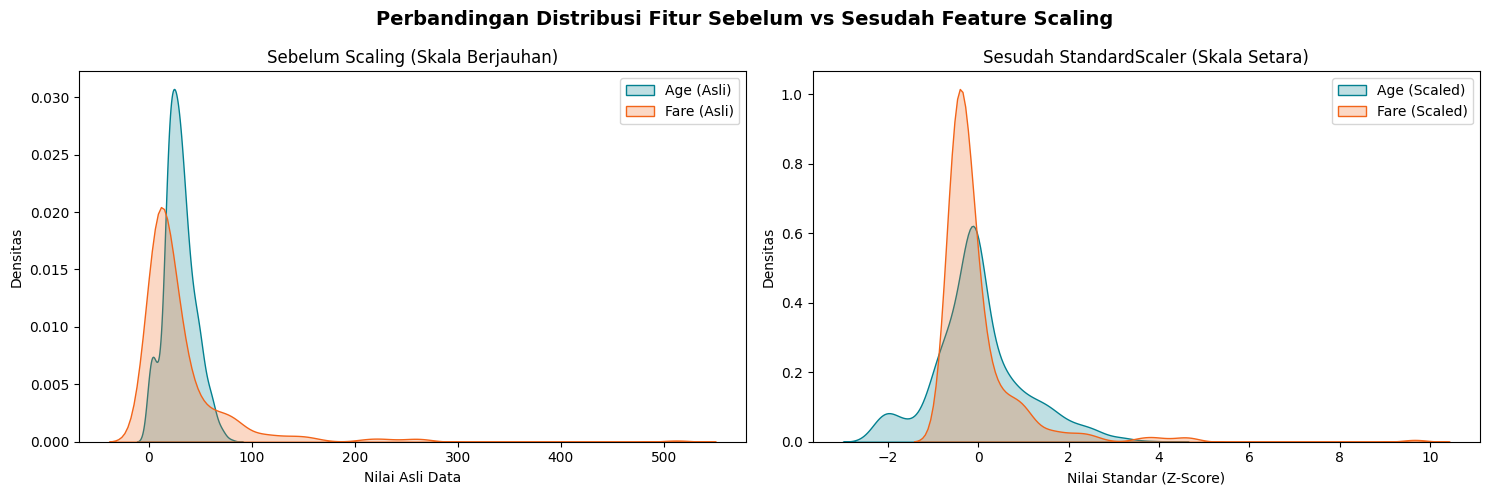

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

# Hubungkan kembali dengan data mentah asli untuk perbandingan visual
df_original = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Membuat subplots 1 baris x 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Perbandingan Distribusi Fitur Sebelum vs Sesudah Feature Scaling', fontsize=14, fontweight='bold')

# 1. Sebelum Scaling (Data Asli)
sns.kdeplot(data=df_original['Age'], label='Age (Asli)', fill=True, color='#028090', ax=axes[0])
sns.kdeplot(data=df_original['Fare'], label='Fare (Asli)', fill=True, color='#F26419', ax=axes[0])
axes[0].set_title('Sebelum Scaling (Skala Berjauhan)')
axes[0].set_xlabel('Nilai Asli Data')
axes[0].set_ylabel('Densitas')
axes[0].legend()

# 2. Sesudah Scaling (StandardScaler)
# df['Age'] dan df['Fare'] diambil dari hasil transformasi StandardScaler di Sel 4 sebelumnya
sns.kdeplot(data=df['Age'], label='Age (Scaled)', fill=True, color='#028090', ax=axes[1])
sns.kdeplot(data=df['Fare'], label='Fare (Scaled)', fill=True, color='#F26419', ax=axes[1])
axes[1].set_title('Sesudah StandardScaler (Skala Setara)')
axes[1].set_xlabel('Nilai Standar (Z-Score)')
axes[1].set_ylabel('Densitas')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Memisahkan Fitur (X) dan Target/Label (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data: 80% Train, 20% Test dengan Stratify agar proporsi kelas target seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah data Train : {len(X_train)} baris")
print(f"Jumlah data Test  : {len(X_test)} baris")
print("\nProporsi Target di Data Train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporsi Target di Data Test:")
print(y_test.value_counts(normalize=True).round(3))

Jumlah data Train : 712 baris
Jumlah data Test  : 179 baris

Proporsi Target di Data Train:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi Target di Data Test:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## Kesimpulan & Analisis Persiapan Data (Titanic Dataset)

### 1. Handling Missing Values
* **Temuan**: Kolom `Age` (numerik) dan `Embarked` (kategorikal) memiliki data yang kosong.
* **Solusi**: Nilai kosong pada `Age` diisi dengan nilai **Median** karena lebih kebal terhadap pencilan (*outliers*), sedangkan `Embarked` diisi dengan **Modus** (nilai yang paling sering muncul).

### 2. Encoding Kategorikal
* Kolom `Sex` diubah menggunakan **Label Encoding** menjadi nilai biner (0 dan 1) karena hanya memiliki dua kategori.
* Kolom `Embarked` diubah menggunakan **One-Hot Encoding** untuk menghindari asumsi urutan tingkatan oleh model machine learning, karena pilihan pelabuhan bersifat nominal murni.

### 3. Feature Scaling
* Skala data mentah antara kolom `Age` dan `Fare` sangat jauh berbeda (ketimpangan skala). Setelah diterapkan **StandardScaler**, kedua fitur tersebut kini berpusat pada nilai rata-rata 0 dengan varians 1, sehingga algoritma berbasis jarak tidak akan bias.

### 4. Pembagian Data (Train-Test Split)
* Data berhasil dipisahkan dengan proporsi **80% untuk pelatihan (Train)** dan **20% untuk pengujian (Test)**.
* Penggunaan parameter `stratify=y` memastikan bahwa rasio persentase penumpang yang selamat (*Survived*) dan tidak selamat tetap seimbang dan sama rata baik di dalam data Train maupun data Test, sehingga mencegah model menjadi bias saat dievaluasi.